In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Only errors are logged
os.environ['TF_GPU_ALLOCATOR'] ='cuda_malloc_async'

import numpy as np
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import layers
from keras import ops

# TF imports related to tf.data preprocessing
from tensorflow import data as tf_data
from tensorflow import image as tf_image
from tensorflow.keras.utils import plot_model

keras.utils.set_random_seed(42)
from sklearn.model_selection import train_test_split

I0000 00:00:1776966731.568964    3251 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776966732.452039    3251 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
BATCH_SIZE = 32
NUM_CLASSES = 8
EPOCHS = 100
SAMPLE_RATE = 16000
OUT_SEQ_LEN = 72000

In [3]:
keras.backend.clear_session(free_memory=True)
train_ds, rest_ds = tf.keras.utils.image_dataset_from_directory(directory='dataset_mfcc_img',
image_size=(300, 300),
subset='both',
batch_size=BATCH_SIZE,
validation_split=0.25,
seed=42)

Found 4240 files belonging to 8 classes.
Using 3180 files for training.
Using 1060 files for validation.


In [4]:
val_ds = rest_ds.take(800)
test_ds = rest_ds.skip(800)


In [5]:
incv3 = keras.applications.InceptionV3(weights=None,include_top=False,input_shape=(300,300,3),pooling='max')
model = keras.Sequential([
  layers.Input(shape=(300,300,3),name='input'),
  # layers.Resizing(299,299),
#   tf.keras.layers.Lambda(tf.image.grayscale_to_rgb),
  incv3,
  # layers.GlobalAveragePooling1D(name='gp'),
  # layers.Flatten(),
  layers.Dense((2048),activation='relu',
              #  ,kernel_regularizer=keras.regularizers.L1L2(l1=0.05)
                  kernel_regularizer=keras.regularizers.L1L2(l1=1e-5, l2=1e-4),
    activity_regularizer=keras.regularizers.L2(1e-5)
               ),  
  layers.Dense((1024),activation='relu'
              #  ,kernel_regularizer=keras.regularizers.L1L2(l1=0.05)
               ),
  # layers.Dropout(0.5),             
  layers.Dense((512),activation='relu',
              #  kernel_regularizer=keras.regularizers.L1L2(l1=0.05)
               ),
  layers.Dense((NUM_CLASSES),activation = 'softmax',name='output')
])

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2048)           │     4,196,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,626,216 (109.20 MB)

 Trainable params: 28,591,784 (109.07 MB)

 Non-trainable params: 34,432 (134.50 KB)

In [7]:
keras.backend.clear_session(free_memory=True)
model.compile(
    optimizer=keras.optimizers.AdamW(),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy()],
)


In [8]:
keras.backend.clear_session(free_memory=True)
history = model.fit(train_ds,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=val_ds,
        callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EPOCHS/10,
            restore_best_weights=True,
        )]
        )

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 87s 415ms/step - loss: 3.6371 - sparse_categorical_accuracy: 0.1491 - val_loss: 2.8420 - val_sparse_categorical_accuracy: 0.1528
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 78ms/step - loss: 2.7531 - sparse_categorical_accuracy: 0.1472 - val_loss: 2.7882 - val_sparse_categorical_accuracy: 0.1292
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 2.5415 - sparse_categorical_accuracy: 0.2340 - val_loss: 4.0234 - val_sparse_categorical_accuracy: 0.1840
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - loss: 2.2332 - sparse_categorical_accuracy: 0.3211 - val_loss: 2.4910 - val_sparse_categorical_accuracy: 0.2764
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 1.9561 - sparse_categorical_accuracy: 0.4314 - val_loss: 6.2984 - val_sparse_categorical_accuracy: 0.2226
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 8s 77ms/step - loss: 1.7401 - sparse_categorical_accuracy: 0.4906 - val_loss: 4.0807 - val_sparse_categorical_accurac

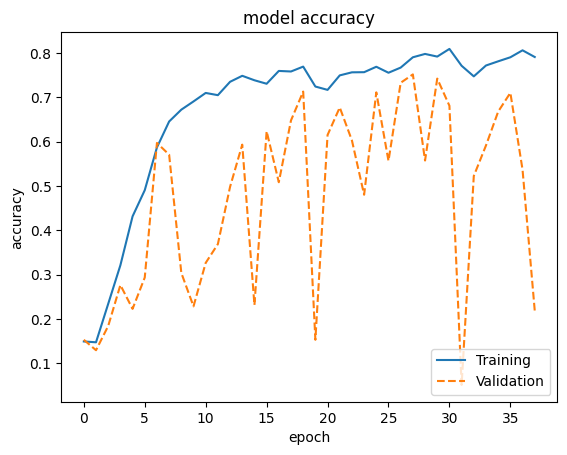

In [9]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'],linestyle='--')
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

In [10]:
model.evaluate(test_ds)

/home/ahmed/workspace/kfupm/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


ValueError: math domain error